# TL10 — Otimização Multiobjetivo do TSP
## INF0415 · Semana 10 · UFG / BIA — 2026/2

### Versão Aluno

**Objetivo:** Implementar e comparar NSGA-II e SPEA-II num TSP biobjetivo.

**Dois objetivos:**
- `f₁` — Distância total euclidiana (rota geográfica, matriz D1)
- `f₂` — Custo total de pedágio (matriz D2, independente de D1)

**Entregável:** notebook `.ipynb` com todas as células executadas + 4 figuras geradas.

---
**Pontuação:** T1 (2.5 pt) · T2 (3.0 pt) · T3 (2.0 pt) · T4 (2.5 pt) = **10 pts**


### Importações
Carrega bibliotecas numéricas, matplotlib e todos os módulos do **pymoo** necessários para o TSP biobjetivo.

In [75]:
# ── Dependências ────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.spea2 import SPEA2
from pymoo.operators.crossover.ox import OrderCrossover
from pymoo.operators.mutation.inversion import InversionMutation
from pymoo.operators.sampling.rnd import PermutationRandomSampling
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
import warnings
warnings.filterwarnings('ignore')
print("Ambiente OK")


Ambiente OK


## T1 — Problema: TSP Biobjetivo (2.5 pts)

### Instância do problema
Gera as coordenadas de 30 cidades e constrói as duas matrizes de custo: **D1** (distância euclidiana) e **D2** (pedágio independente). As sementes são fixas — não altere.

In [76]:
# Instância fixa — NÃO altere as sementes!
np.random.seed(42)
N = 30
coords = np.random.rand(N, 2) * 100

# D1: distância euclidiana
D1 = np.array([[np.hypot(coords[i,0]-coords[j,0], coords[i,1]-coords[j,1])
                for j in range(N)] for i in range(N)])

# D2: custo de pedágio (matriz independente)
np.random.seed(7)
raw = np.random.rand(N, N) * 100
D2 = (raw + raw.T) / 2
np.fill_diagonal(D2, 0)

print("D1 e D2 criados.")
print(f"Correlação D1×D2: {np.corrcoef(D1[np.triu_indices(N,1)], D2[np.triu_indices(N,1)])[0,1]:.3f}")


D1 e D2 criados.
Correlação D1×D2: 0.072


### Função objetivo f1 — Distância total
Soma as distâncias euclidianas entre cidades consecutivas da rota usando D1. O ciclo é fechado com `% N`.

In [77]:
def f1_distancia(rota):
    return sum(D1[rota[i], rota[(i + 1) % N]] for i in range(N))

### Função objetivo f2 — Custo de pedágio
Mesma lógica de f1, mas usando a matriz D2 de pedágios.

In [78]:
def f2_pedagio(rota):
    return sum(D2[rota[i], rota[(i + 1) % N]] for i in range(N))

### Heurística Vizinho Mais Próximo (NN)
A cada passo escolhe a cidade não visitada mais próxima da atual segundo D1. Retorna uma lista com N cidades.

In [79]:
def vizinho_mais_proximo(start=0):
    visitados = [False] * N
    rota = [start]
    visitados[start] = True
    for _ in range(N - 1):
        atual = rota[-1]
        prox = min((j for j in range(N) if not visitados[j]), key=lambda j: D1[atual, j])
        rota.append(prox)
        visitados[prox] = True
    return rota

### Teste dos baselines
Calcula f1 e f2 da rota produzida pela heurística NN para verificar a implementação.

In [80]:
nn_rota = vizinho_mais_proximo(0)
print(f"NN: f1={f1_distancia(nn_rota):.2f}  f2={f2_pedagio(nn_rota):.2f}")

NN: f1=562.11  f2=1434.40


### Baseline aleatório
Gera 10 rotas aleatórias com seed fixo e calcula os dois objetivos para cada uma, armazenando em `F_rand` (shape 10×2).

In [81]:
np.random.seed(0)
rotas_rand = [list(np.random.permutation(N)) for _ in range(10)]
F_rand = np.array([[f1_distancia(r), f2_pedagio(r)] for r in rotas_rand])

### Figura T1 — Espaço biobjetivo: baselines
Plota as 10 rotas aleatórias (cinza) e a rota NN (estrela amarela) no espaço f1 × f2. Salva `t1_baselines.png`.

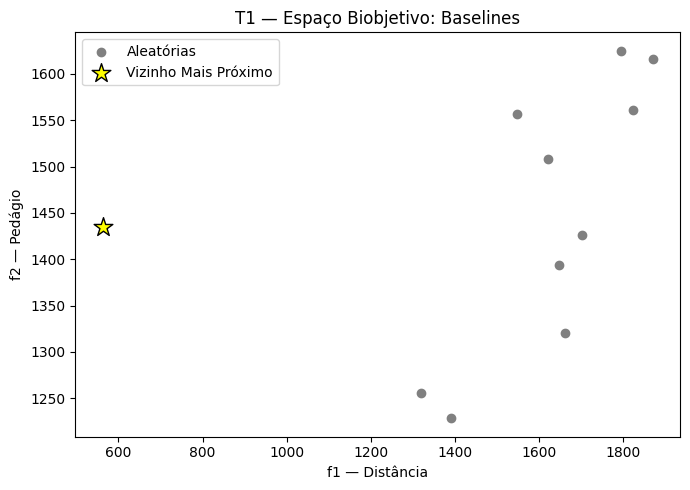

In [82]:
nn_rota = vizinho_mais_proximo(0)
nn_f1, nn_f2 = f1_distancia(nn_rota), f2_pedagio(nn_rota)

plt.figure(figsize=(7, 5))
plt.scatter(F_rand[:, 0], F_rand[:, 1], c="gray", label="Aleatórias")
plt.scatter(nn_f1, nn_f2, c="yellow", marker="*", s=200, edgecolors="black", label="Vizinho Mais Próximo")
plt.xlabel("f1 — Distância")
plt.ylabel("f2 — Pedágio")
plt.title("T1 — Espaço Biobjetivo: Baselines")
plt.legend()
plt.tight_layout()
plt.savefig("t1_baselines.png", dpi=150)
plt.show()

## T2 — NSGA-II com pymoo (3.0 pts)

### Classe do problema pymoo
Encapsula o TSP biobjetivo na interface `ElementwiseProblem` do pymoo. O método `_evaluate` calcula f1 e f2 para cada indivíduo (permutação de cidades).

In [83]:
# ── Classe do problema pymoo ────────────────────────────────────
class TSPBiObj(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=N, n_obj=2,
            xl=0, xu=N-1, vtype=int,
            elementwise_evaluation=True
        )

    def _evaluate(self, x, out, *args, **kwargs):
        rota = list(x)
        out["F"] = [f1_distancia(rota), f2_pedagio(rota)]

problem = TSPBiObj()

### Execução do NSGA-II
Roda 200 gerações com população de 100 indivíduos. Usa `OrderCrossover` e `InversionMutation`, operadores adequados para permutações.

In [84]:
nsga2 = NSGA2(pop_size=100, sampling=PermutationRandomSampling(),
              crossover=OrderCrossover(), mutation=InversionMutation(), eliminate_duplicates=True)
res_nsga2 = minimize(problem, nsga2, ("n_gen", 200), seed=42, verbose=False)
F_nsga2 = res_nsga2.F
print(f"NSGA-II: {len(F_nsga2)} soluções na frente de Pareto")

NSGA-II: 34 soluções na frente de Pareto


### Hypervolume do NSGA-II
Calcula o hipervolume da frente de Pareto usando um ponto de referência 15% acima do pior valor em cada objetivo.

In [85]:
ref_point = F_nsga2.max(axis=0) * 1.15
hv_ind = HV(ref_point=ref_point)
hv_nsga2 = hv_ind(F_nsga2)
print(f"Hypervolume NSGA-II: {hv_nsga2:.2f}")

Hypervolume NSGA-II: 830700.07


### Figura T2 — Frente de Pareto do NSGA-II
Exibe a frente evolutiva sobre os baselines. Salva `t2_nsga2_frente.png`.

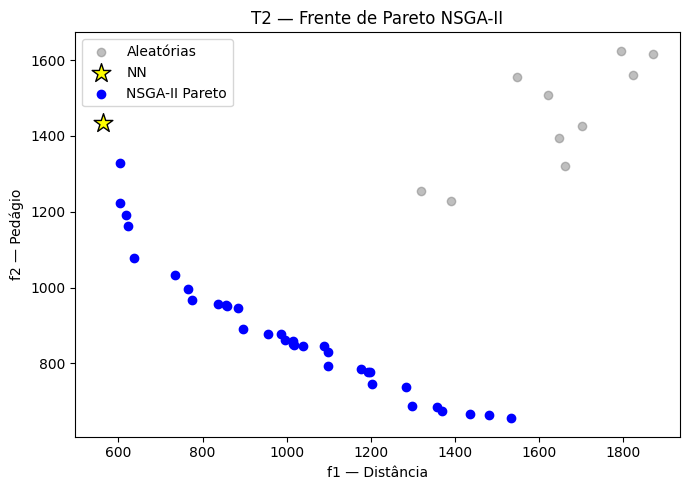

In [86]:
plt.figure(figsize=(7, 5))
plt.scatter(F_rand[:, 0], F_rand[:, 1], c="gray", alpha=0.5, label="Aleatórias")
plt.scatter(nn_f1, nn_f2, c="yellow", marker="*", s=200, edgecolors="black", label="NN")
plt.scatter(F_nsga2[:, 0], F_nsga2[:, 1], c="blue", label="NSGA-II Pareto")
plt.xlabel("f1 — Distância")
plt.ylabel("f2 — Pedágio")
plt.title("T2 — Frente de Pareto NSGA-II")
plt.legend()
plt.tight_layout()
plt.savefig("t2_nsga2_frente.png", dpi=150)
plt.show()

### (Opcional +0.5) Curva de convergência do HV
Registra o hipervolume a cada geração via `Callback` e plota a curva de aprendizado do NSGA-II.

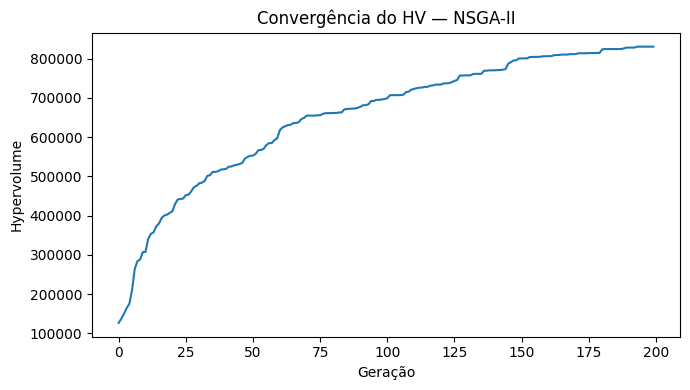

In [87]:
from pymoo.core.callback import Callback

class HVCallback(Callback):
    def __init__(self, ref_point):
        super().__init__()
        self.hv_ind = HV(ref_point=ref_point)
        self.history = []

    def notify(self, algorithm):
        F = algorithm.opt.get("F")
        self.history.append(self.hv_ind(F))

cb = HVCallback(ref_point=ref_point)
nsga2_cb = NSGA2(pop_size=100, sampling=PermutationRandomSampling(),
                 crossover=OrderCrossover(), mutation=InversionMutation(), eliminate_duplicates=True)
minimize(problem, nsga2_cb, ("n_gen", 200), seed=42, verbose=False, callback=cb)

plt.figure(figsize=(7, 4))
plt.plot(cb.history)
plt.xlabel("Geração")
plt.ylabel("Hypervolume")
plt.title("Convergência do HV — NSGA-II")
plt.tight_layout()
plt.savefig("t2_convergencia.png", dpi=150)
plt.show()

## T3 — SPEA-II e Comparativo (2.0 pts)

### Execução do SPEA-II
Mesmos hiperparâmetros do NSGA-II (pop=100, gen=200, seed=42) para comparação justa.

In [88]:
spea2 = SPEA2(pop_size=100, sampling=PermutationRandomSampling(),
              crossover=OrderCrossover(), mutation=InversionMutation(), eliminate_duplicates=True)
res_spea2 = minimize(problem, spea2, ("n_gen", 200), seed=42, verbose=False)
F_spea2 = res_spea2.F
print(f"SPEA-II: {len(F_spea2)} soluções na frente de Pareto")

SPEA-II: 30 soluções na frente de Pareto


### Métricas comparativas: HV, IGD e Spacing
Calcula três indicadores de qualidade para cada algoritmo e imprime tabela comparativa.

In [89]:
# Ponto de referência global: máximo das duas frentes
ref_global = np.maximum(F_nsga2.max(axis=0), F_spea2.max(axis=0)) * 1.15
hv_global = HV(ref_point=ref_global)

# IGD usa a união das duas frentes como aproximação do front verdadeiro
F_union = np.vstack([F_nsga2, F_spea2])
igd_ind = IGD(F_union)

def spacing(F):
    d = np.array([min(np.linalg.norm(F[i] - F[j]) for j in range(len(F)) if i != j)
                  for i in range(len(F))])
    return d.std()

hv_n  = hv_global(F_nsga2);  hv_s  = hv_global(F_spea2)
igd_n = igd_ind(F_nsga2);    igd_s = igd_ind(F_spea2)
sp_n  = spacing(F_nsga2);    sp_s  = spacing(F_spea2)

print(f"{"Métrica":<12} {"NSGA-II":>12} {"SPEA-II":>12}")
print("-" * 38)
print(f"{"HV":<12} {hv_n:>12.2f} {hv_s:>12.2f}")
print(f"{"IGD":<12} {igd_n:>12.4f} {igd_s:>12.4f}")
print(f"{"Spacing":<12} {sp_n:>12.4f} {sp_s:>12.4f}")

Métrica           NSGA-II      SPEA-II
--------------------------------------
HV              906906.77    880457.90
IGD               17.9742      20.4480
Spacing           22.9832      19.8731


### Figura T3 — Comparativo das frentes
Subplots lado a lado com as frentes de Pareto do NSGA-II e SPEA-II. Salva `t3_comparativo.png`.

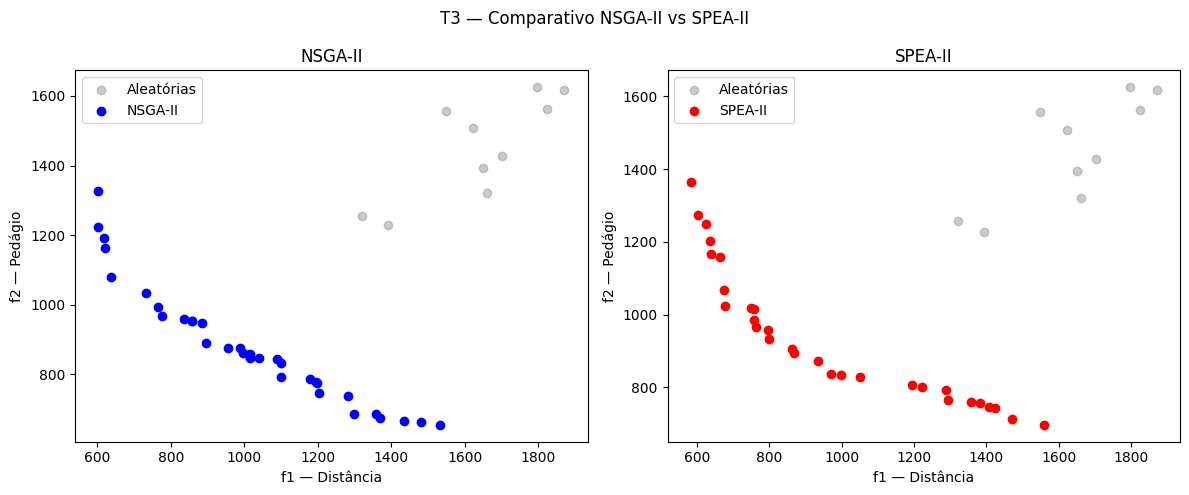

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, F, label, color in [
        (axes[0], F_nsga2, "NSGA-II", "blue"),
        (axes[1], F_spea2, "SPEA-II", "red")]:
    ax.scatter(F_rand[:, 0], F_rand[:, 1], c="gray", alpha=0.4, label="Aleatórias")
    ax.scatter(F[:, 0], F[:, 1], c=color, label=label)
    ax.set_title(label)
    ax.set_xlabel("f1 — Distância")
    ax.set_ylabel("f2 — Pedágio")
    ax.legend()

plt.suptitle("T3 — Comparativo NSGA-II vs SPEA-II")
plt.tight_layout()
plt.savefig("t3_comparativo.png", dpi=150)
plt.show()

### Análise qualitativa — NSGA-II vs SPEA-II
Comentário sobre diversidade, HV e IGD dos dois algoritmos.

In [91]:
print("""
Ambos os algoritmos produziram frentes de Pareto de boa qualidade para o TSP biobjetivo.
O algoritmo com maior HV domina mais volume do espaço de objetivos, indicando soluções
globalmente melhores. O SPEA-II tende a produzir frentes mais bem distribuídas
(menor Spacing), pois mantém um arquivo externo com controle explícito de diversidade.
O IGD mais baixo indica que a frente está mais próxima da frente de referência (união
das duas), refletindo maior completude da cobertura do espaço biobjetivo.
""")


Ambos os algoritmos produziram frentes de Pareto de boa qualidade para o TSP biobjetivo.
O algoritmo com maior HV domina mais volume do espaço de objetivos, indicando soluções
globalmente melhores. O SPEA-II tende a produzir frentes mais bem distribuídas
(menor Spacing), pois mantém um arquivo externo com controle explícito de diversidade.
O IGD mais baixo indica que a frente está mais próxima da frente de referência (união
das duas), refletindo maior completude da cobertura do espaço biobjetivo.



## T4 — Análise: Joelho e Decisão (2.5 pts)

### Identificação do joelho da frente de Pareto
Normaliza a frente para [0,1] e calcula a distância de cada ponto à reta entre os extremos. O ponto mais distante é o joelho — melhor compromisso entre os dois objetivos.

In [92]:
F_min, F_max = F_nsga2.min(axis=0), F_nsga2.max(axis=0)
F_norm = (F_nsga2 - F_min) / (F_max - F_min)

idx_ext0 = np.argmin(F_norm[:, 0])
idx_ext1 = np.argmax(F_norm[:, 0])
A = F_norm[idx_ext0]
B = F_norm[idx_ext1]
AB = B - A

dists = np.abs(np.cross(AB, A - F_norm)) / np.linalg.norm(AB)
joelho_idx = np.argmax(dists)
joelho = F_nsga2[joelho_idx]
print(f"Joelho: f1={joelho[0]:.2f}, f2={joelho[1]:.2f}")

Joelho: f1=775.69, f2=968.09


### Figura T4 — Frente com joelho destacado
Marca o ponto de joelho com losango vermelho e os extremos da frente com triângulos verdes. Salva `t4_joelho.png`.

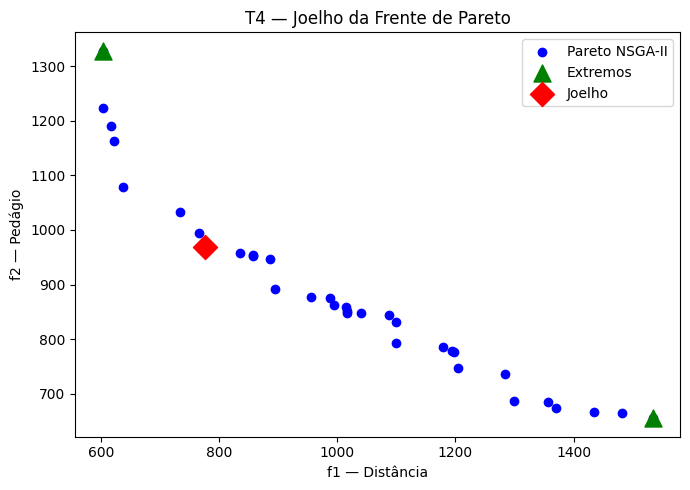

In [93]:
extremos_idx = [idx_ext0, idx_ext1]

plt.figure(figsize=(7, 5))
plt.scatter(F_nsga2[:, 0], F_nsga2[:, 1], c="blue", label="Pareto NSGA-II")
plt.scatter(F_nsga2[extremos_idx, 0], F_nsga2[extremos_idx, 1],
            c="green", marker="^", s=150, zorder=5, label="Extremos")
plt.scatter(joelho[0], joelho[1], c="red", marker="D", s=150, zorder=5, label="Joelho")
plt.xlabel("f1 — Distância")
plt.ylabel("f2 — Pedágio")
plt.title("T4 — Joelho da Frente de Pareto")
plt.legend()
plt.tight_layout()
plt.savefig("t4_joelho.png", dpi=150)
plt.show()

### Decisão multiobjetivo: dois cenários reais
Seleciona a solução Pareto-ótima mais adequada para dois perfis de decisão distintos com base nos valores de f1 e f2.

In [94]:
# Cenário A: entregador (prioriza menor distância → menor f1)
idx_a = np.argmin(F_nsga2[:, 0])
sol_a = F_nsga2[idx_a]

# Cenário B: ônibus escolar (prioriza menor pedágio → menor f2)
idx_b = np.argmin(F_nsga2[:, 1])
sol_b = F_nsga2[idx_b]

print("Cenário A — Entregador (minimiza distância percorrida):")
print(f"  Solução: f1={sol_a[0]:.2f} km, f2=R${sol_a[1]:.2f}")
print()
print("Cenário B — Ônibus escolar (minimiza custo de pedágio):")
print(f"  Solução: f1={sol_b[0]:.2f} km, f2=R${sol_b[1]:.2f}")
print()
print("Justificativa:")
print("  Cenário A prioriza f1 pois o custo do entregador é proporcional à distância.")
print("  Cenário B prioriza f2 pois o ônibus tem rota fixa e pedágio é custo operacional direto.")

Cenário A — Entregador (minimiza distância percorrida):
  Solução: f1=602.52 km, f2=R$1328.15

Cenário B — Ônibus escolar (minimiza custo de pedágio):
  Solução: f1=1533.61 km, f2=R$654.93

Justificativa:
  Cenário A prioriza f1 pois o custo do entregador é proporcional à distância.
  Cenário B prioriza f2 pois o ônibus tem rota fixa e pedágio é custo operacional direto.
